# 5th Year MS Technical Report RQ2

## Setup

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sqlite3
import json
from enum import Enum

In [ ]:
class Term(Enum):
    SPRING = 0
    SUMMER = 1
    FALL = 2

    def __str__(self):
        return self.name.capitalize()

    def short_name(self):
        if self == Term.SPRING:
            return "sp"
        elif self == Term.SUMMER:
            return "su"
        else:
            return "fa"


class Course:
    cs61a: bool
    term: Term
    year: int

    def __init__(self, cs61a: bool, term: Term, year: int):
        self.cs61a = cs61a
        self.term = term
        self.term_string = term.short_name() + str(year)[2:]
        self.year = year

    def __str__(self):
        return f"{'CS 61A' if self.cs61a else 'DATA C88C'} {self.term} {self.year}"

    def __repr__(self):
        return f"Course(cs61a={self.cs61a}, term={repr(self.term)}, year={self.year})"

    def __eq__(self, other):
        if isinstance(other, Course):
            return (
                self.cs61a == other.cs61a
                and self.term == other.term
                and self.year == other.year
            )
        return NotImplemented

    def __hash__(self):
        return hash(str(self))

In [31]:
courses = []

for year in (2024, 2025):
    for term in (Term.SPRING, Term.SUMMER, Term.FALL):
        for cs61a in (True, False):
            courses.append(Course(cs61a, term, year))

courses = [
    Course(True, Term.FALL, 2023),
    Course(False, Term.FALL, 2023),
] + courses

assert len(courses) == 14

for c in courses:
    print(c)

CS 61A Fall 2023
DATA C88C Fall 2023
CS 61A Spring 2024
DATA C88C Spring 2024
CS 61A Summer 2024
DATA C88C Summer 2024
CS 61A Fall 2024
DATA C88C Fall 2024
CS 61A Spring 2025
DATA C88C Spring 2025
CS 61A Summer 2025
DATA C88C Summer 2025
CS 61A Fall 2025
DATA C88C Fall 2025


In [ ]:
PATH_PREFIX = "../../data/private/out"


def get_db_cursor(course: Course) -> tuple[sqlite3.Connection, sqlite3.Cursor]:
    conn = sqlite3.connect(
        f"{PATH_PREFIX}/{'cs61a' if course.cs61a else 'datac88c'}/{course.term_string}/snapshots.db"
    )
    conn.row_factory = sqlite3.Row
    return conn, conn.cursor()

In [33]:
conns_curs = [get_db_cursor(course) for course in courses]
conns = [conn for conn, _ in conns_curs]
cursors = [cur for _, cur in conns_curs]

In [ ]:
results = {}

## How many backups are there per student?

In [ ]:
def backups_per_student(cur: sqlite3.Cursor) -> np.array:
    cur.execute("SELECT COUNT(*) FROM backup_metadata GROUP BY student_email")
    return np.array([row[0] for row in cur.fetchall()])

In [ ]:
results["backups_per_student"] = {}

for course, cur in zip(courses, cursors):
    results["backups_per_student"][course] = backups_per_student(cur)

<Axes: ylabel='Count'>

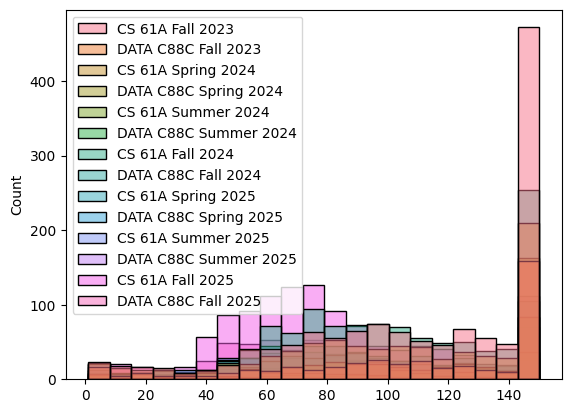

In [39]:
sns.histplot(data=results["backups_per_student"])

<Axes: ylabel='Count'>

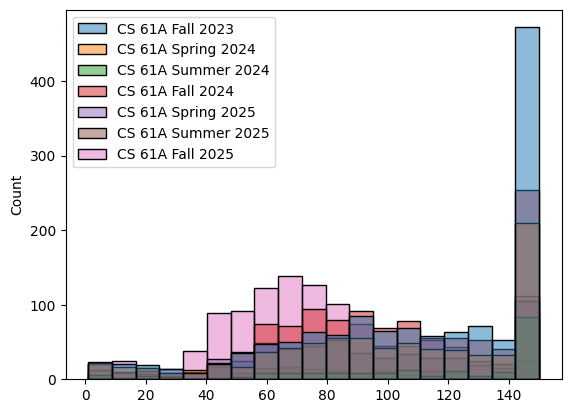

In [ ]:
sns.histplot(
    data={key: val for key, val in results["backups_per_student"].items() if key.cs61a}
)

<Axes: ylabel='Count'>

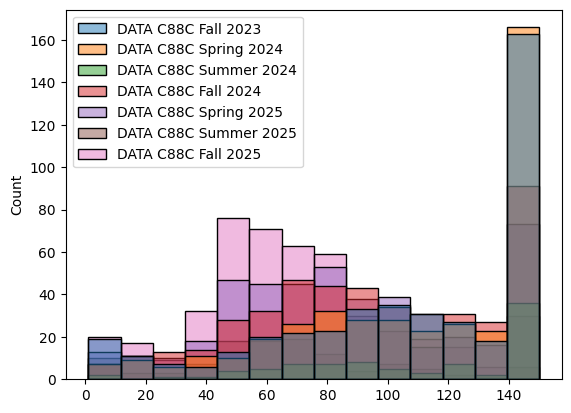

In [ ]:
sns.histplot(
    data={
        key: val for key, val in results["backups_per_student"].items() if not key.cs61a
    }
)

<Axes: ylabel='Percent'>

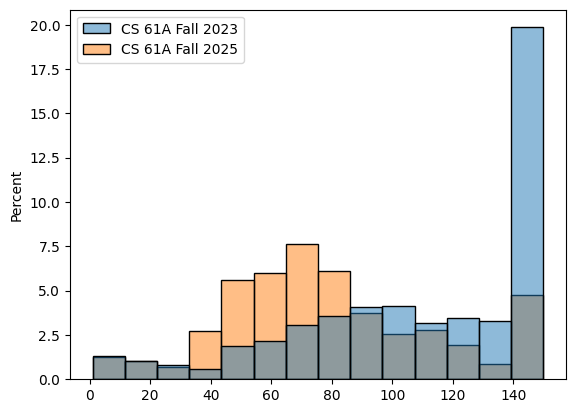

In [ ]:
sns.histplot(
    data={
        key: val
        for key, val in results["backups_per_student"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
    stat="percent",
)

<Axes: ylabel='Percent'>

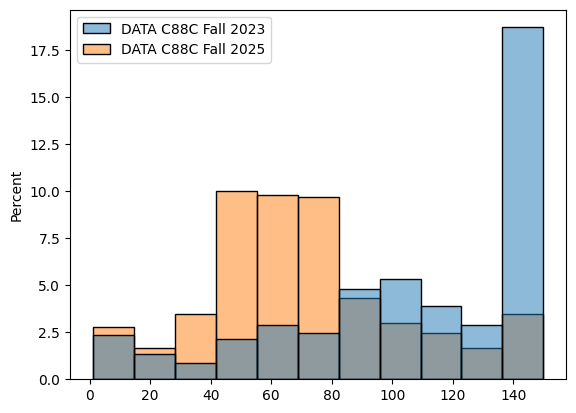

In [ ]:
sns.histplot(
    data={
        key: val
        for key, val in results["backups_per_student"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
    stat="percent",
)

In [ ]:
bps_median = {"Course": [], "Term": [], "Backups per student (median)": []}

for course, cur in zip(courses, cursors):
    bps_median["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    bps_median["Term"].append(course.term_string.upper())
    bps_median["Backups per student (median)"].append(
        np.median(results["backups_per_student"][course])
    )

<Axes: xlabel='Term', ylabel='Backups per student (median)'>

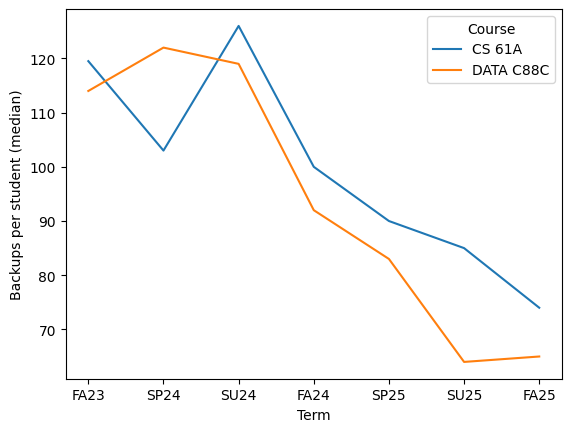

In [65]:
sns.lineplot(data=bps_median, x="Term", y="Backups per student (median)", hue="Course")

- Consistent downward trend in number of backups per student (caveat: ceiling effect due to limit 150 backups, but ceiling effect vanishes for sure by FA25)
- Only difference between courses: SP24. Possibly because 61Abot wide release that semester while C88C did not use it yet?

## Total time spent

In [72]:
def total_time_spent(cursor: sqlite3.Cursor) -> np.array:
    cursor.execute("""
        SELECT julianday(MAX(created)) - julianday(MIN(created)) AS total_time_spent_days
        FROM backup_metadata
        GROUP BY student_email
    """)
    return np.array([row[0] for row in cursor.fetchall()])

In [73]:
results["total_time_spent_days"] = {}

for course, cur in zip(courses, cursors):
    results["total_time_spent_days"][course] = total_time_spent(cur)

<Axes: ylabel='Count'>

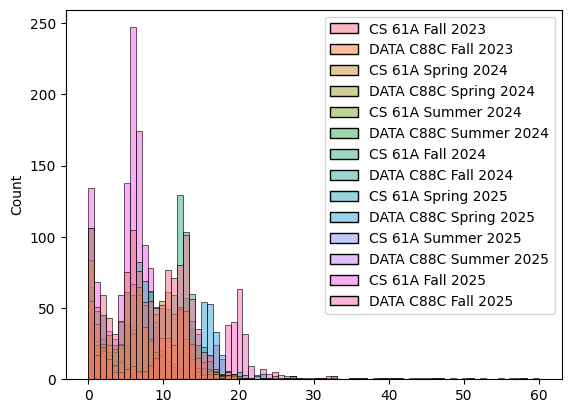

In [77]:
sns.histplot(data=results["total_time_spent_days"], binrange=(0, 60))

<Axes: ylabel='Percent'>

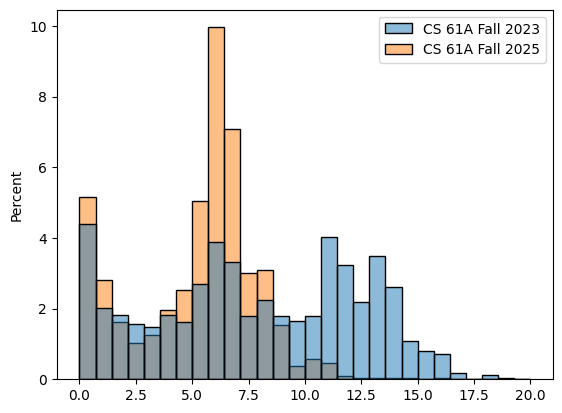

In [ ]:
sns.histplot(
    data={
        key: val
        for key, val in results["total_time_spent_days"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
    stat="percent",
    binrange=(0, 20),
)

<Axes: ylabel='Percent'>

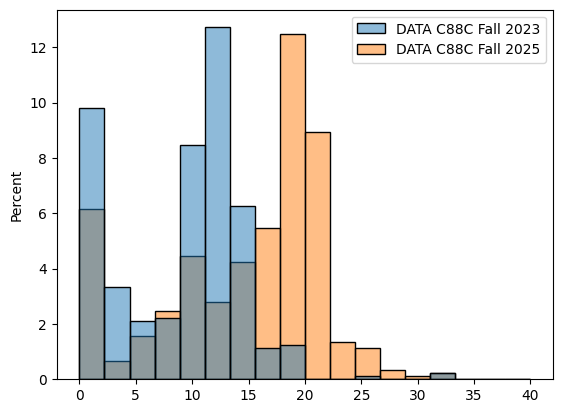

In [ ]:
sns.histplot(
    data={
        key: val
        for key, val in results["total_time_spent_days"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
    stat="percent",
    binrange=(0, 40),
)

In [ ]:
tts_median = {
    "Course": [],
    "Term": [],
    "Median total time spent (days) per student": [],
}

for course, cur in zip(courses, cursors):
    tts_median["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    tts_median["Term"].append(course.term_string.upper())
    tts_median["Median total time spent (days) per student"].append(
        np.median(results["total_time_spent_days"][course])
    )

<Axes: xlabel='Term', ylabel='Median total time spent (days) per student'>

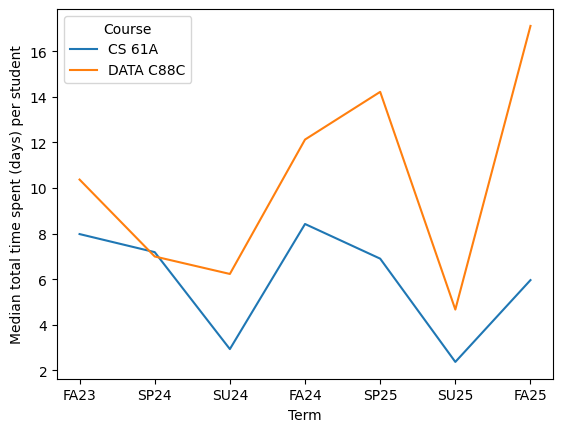

In [ ]:
sns.lineplot(
    data=tts_median,
    x="Term",
    y="Median total time spent (days) per student",
    hue="Course",
)

## Total active time spent

In [ ]:
# TODO

## Problems solved by last backup

In [ ]:
def problems_solved_by_last_backup(cursor: sqlite3.Cursor) -> np.array:
    def count_problems_solved(history: list[dict]) -> int:
        solved = 0
        for problem in history:
            if problem["solved"]:
                solved += 1
        return solved

    cursor.execute("""
    WITH last_backups AS (
        SELECT
            student_email,
            backup_id,
            MAX(created) AS last_created
        FROM backup_metadata
        GROUP BY student_email
    )

    SELECT
        lb.*,
        history
    FROM analytics_messages AS am
    JOIN last_backups AS lb
    ON am.backup_id = lb.backup_id
    """)
    # list of lists, where inner list contains JSON objects representing problem solve state
    # 1 inner list per student
    last_backup_analytics_histories = [json.loads(row[3]) for row in cursor.fetchall()]

    # flatten using count_problems_solved
    # returns 1D list of len(students)
    return np.array(list(map(count_problems_solved, last_backup_analytics_histories)))

In [ ]:
results["problems_solved_by_last_backup"] = {}

for course, cur in zip(courses, cursors):
    results["problems_solved_by_last_backup"][course] = problems_solved_by_last_backup(
        cur
    )

<Axes: ylabel='Percent'>

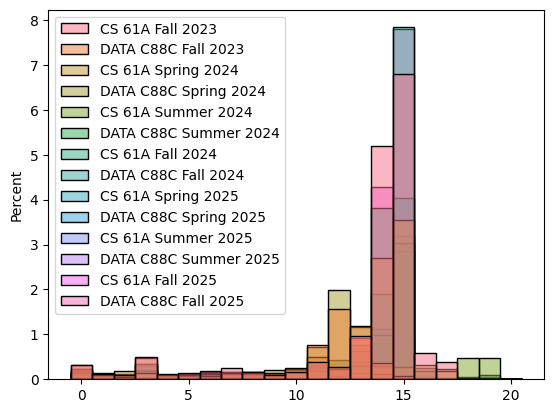

In [ ]:
sns.histplot(
    data=results["problems_solved_by_last_backup"],
    stat="percent",
    binrange=(0, 20),
    discrete=True,
)

<Axes: ylabel='Percent'>

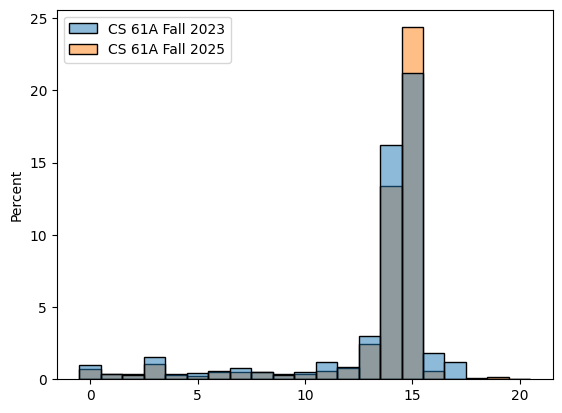

In [ ]:
sns.histplot(
    data={
        key: val
        for key, val in results["problems_solved_by_last_backup"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
    stat="percent",
    binrange=(0, 20),
    discrete=True,
)

<Axes: ylabel='Percent'>

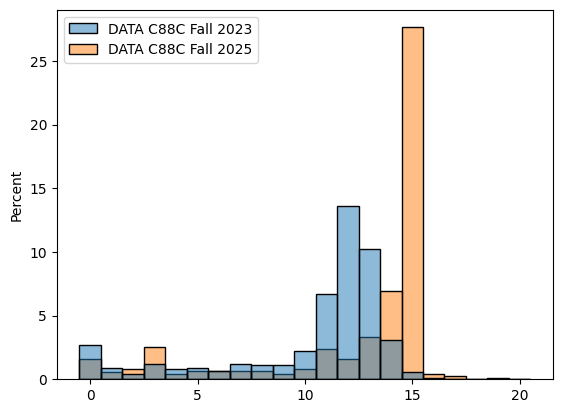

In [ ]:
sns.histplot(
    data={
        key: val
        for key, val in results["problems_solved_by_last_backup"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
    stat="percent",
    binrange=(0, 20),
    discrete=True,
)

In [113]:
percent_students_finish = {
    "Course": [],
    "Term": [],
    "% of students who finish by last backup": [],
}

for course, cur in zip(courses, cursors):
    percent_students_finish["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    percent_students_finish["Term"].append(course.term_string.upper())

    num_students_finish = np.sum(
        results["problems_solved_by_last_backup"][course] >= 15
    )
    total_students = len(results["problems_solved_by_last_backup"][course])
    percent = (num_students_finish / total_students) * 100
    percent_students_finish[
        "% of students who finish by last backup"
    ].append(percent)

<Axes: xlabel='Term', ylabel='% of students who finish by last backup'>

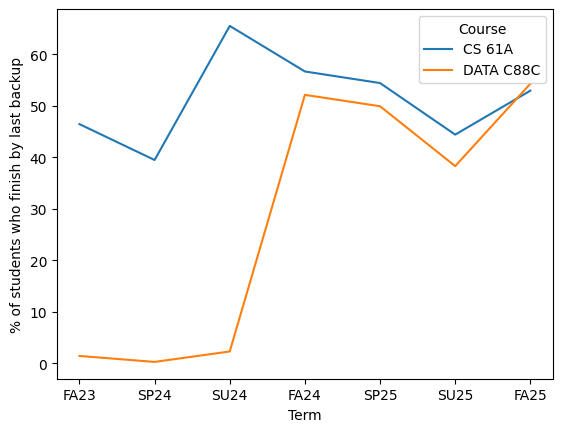

In [114]:
sns.lineplot(
    data=percent_students_finish,
    x="Term",
    y="% of students who finish by last backup",
    hue="Course",
)

## Problem(s) solved per day

In [102]:
problems_per_day = {
    "Course": [],
    "Term": [],
    "Median problems solved per day": [],
}

for course, cur in zip(courses, cursors):
    problems_per_day["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    problems_per_day["Term"].append(course.term_string.upper())

    median_problems_solved = np.median(results["problems_solved_by_last_backup"][course])
    median_total_time_spent_days = np.median(results["total_time_spent_days"][course])
    problems_per_day["Median problems solved per day"].append(median_problems_solved / median_total_time_spent_days)

<Axes: xlabel='Term', ylabel='Median problems solved per day'>

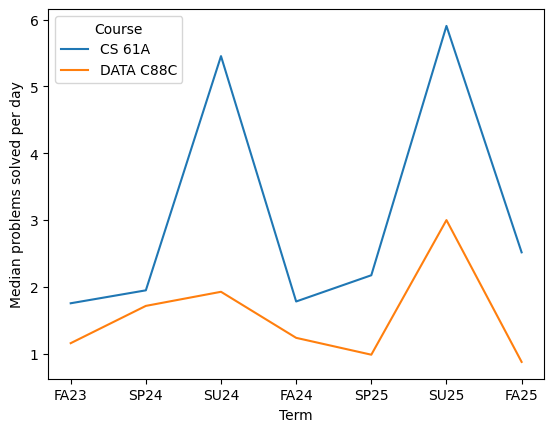

In [103]:
sns.lineplot(
    data=problems_per_day,
    x="Term",
    y="Median problems solved per day",
    hue="Course",
)

## Autograder spam

In [ ]:
AG_SPAM_QUERY = """
WITH raw_time AS (
    -- Convert ISO8601 strings to unix timestamps for math
    SELECT
        student_email,
        strftime('%s', created) AS ts
    FROM backup_metadata
),
time_diffs AS (
    -- Get the timestamp of the previous backup for each student
    SELECT
        student_email,
        ts,
        LAG(ts) OVER (PARTITION BY student_email ORDER BY ts) AS prev_ts
    FROM raw_time
),
session_starts AS (
    -- Identify the start of a new session (gap > 900 seconds or 15 min)
    SELECT
        student_email,
        ts,
        CASE
            WHEN ts - prev_ts > 900 THEN 1
            ELSE 0
        END AS is_new_session
    FROM time_diffs
),
session_groups AS (
    -- Create a unique session_id by calculating a running sum of starts
    SELECT
        student_email,
        ts,
        SUM(is_new_session) OVER (PARTITION BY student_email ORDER BY ts) AS session_id
    FROM session_starts
),
worksession_stats AS (
    -- Aggregate by student and session_id
    SELECT
        student_email,
        COUNT(*) AS backup_count,
        (MAX(ts) - MIN(ts)) / 60.0 AS duration_minutes
    FROM session_groups
    GROUP BY student_email, session_id
)
-- Compute the final rate (handling 0-minute sessions to avoid division by zero)
SELECT
    student_email,
    CASE
        WHEN duration_minutes = 0 THEN 1.0  -- One backup is technically "1 per moment"
        ELSE backup_count / duration_minutes
    END AS backups_per_minute
FROM worksession_stats;
"""

def backups_per_minute(cursor: sqlite3.Cursor) -> np.array:
    cursor.execute(AG_SPAM_QUERY)
    return np.array([row["backups_per_minute"] for row in cursor.fetchall()])

In [105]:
results["backups_per_minute"] = {}

for course, cur in zip(courses, cursors):
    results["backups_per_minute"][course] = backups_per_minute(cur)

<Axes: ylabel='Count'>

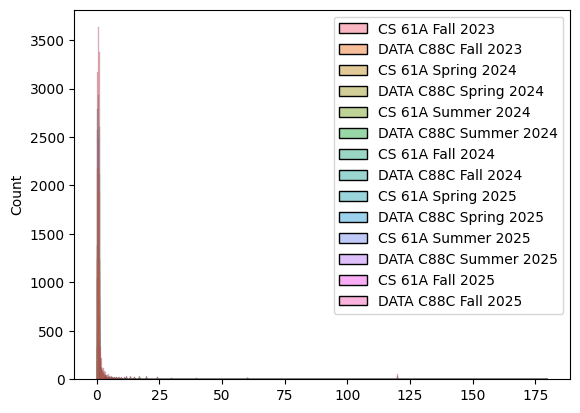

In [106]:
sns.histplot(data=results["backups_per_minute"])

<Axes: ylabel='Count'>

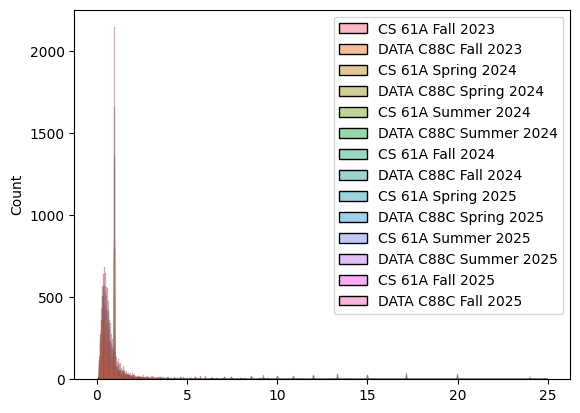

In [107]:
sns.histplot(data=results["backups_per_minute"], binrange=(0, 25))

<Axes: ylabel='Percent'>

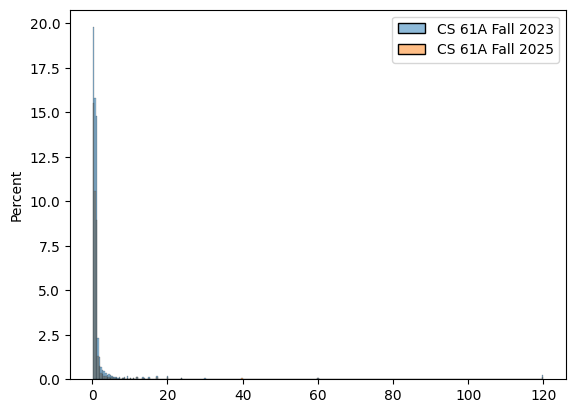

In [ ]:
sns.histplot(
    data={
        key: val
        for key, val in results["backups_per_minute"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
    stat="percent",
)

<Axes: ylabel='Percent'>

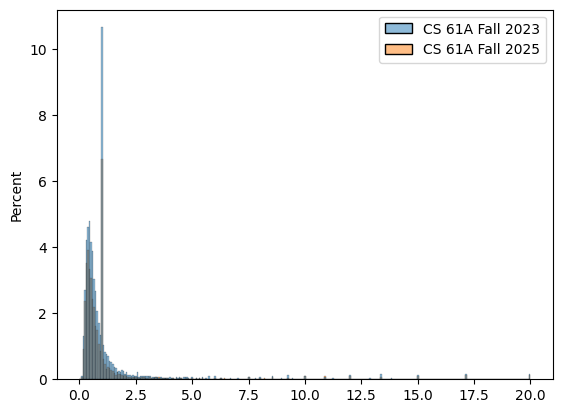

In [111]:
sns.histplot(
    data={
        key: val
        for key, val in results["backups_per_minute"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
    stat="percent",
    binrange=(0, 20),
)

<Axes: ylabel='Percent'>

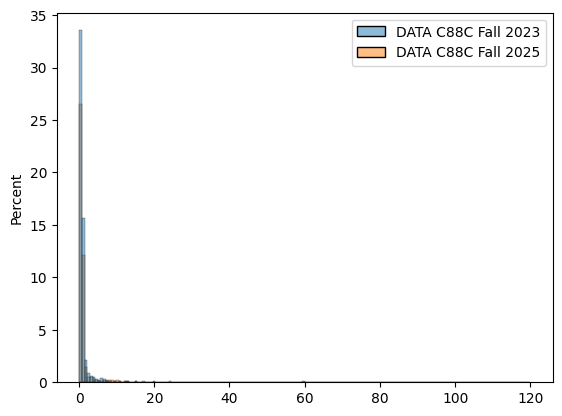

In [109]:
sns.histplot(
    data={
        key: val
        for key, val in results["backups_per_minute"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
    stat="percent",
)

<Axes: ylabel='Percent'>

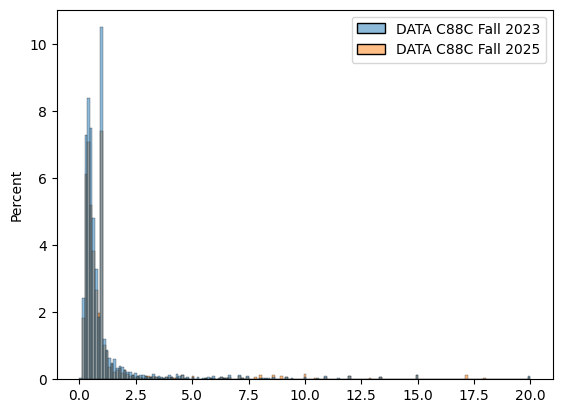

In [112]:
sns.histplot(
    data={
        key: val
        for key, val in results["backups_per_minute"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
    stat="percent",
    binrange=(0, 20),
)

In [116]:
percent_ag_spam = {
    "Course": [],
    "Term": [],
    # defined as > 1 backup/minute
    "% of students who autograder spam": [],
}

for course, cur in zip(courses, cursors):
    percent_ag_spam["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    percent_ag_spam["Term"].append(course.term_string.upper())

    num_students_spam = np.sum(
        results["backups_per_minute"][course] > 1
    )
    total_students = len(results["backups_per_minute"][course])
    percent = (num_students_spam / total_students) * 100
    percent_ag_spam[
        "% of students who autograder spam"
    ].append(percent)

<Axes: xlabel='Term', ylabel='% of students who autograder spam'>

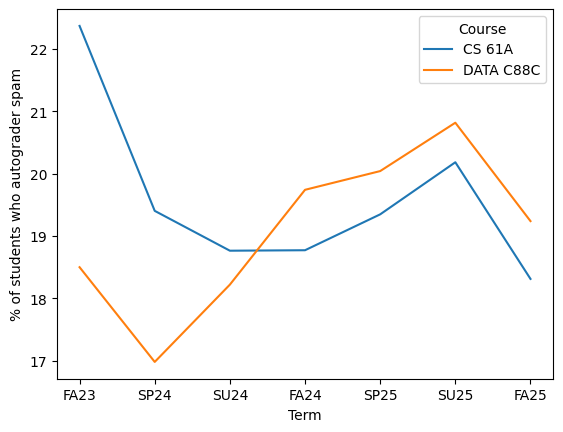

In [117]:
sns.lineplot(
    data=percent_ag_spam,
    x="Term",
    y="% of students who autograder spam",
    hue="Course",
)

## Time between backups

In [119]:
TIME_BTWN_BACKUPS_QUERY = """
WITH raw_time AS (
    -- Convert ISO8601 strings to unix timestamps
    SELECT
        student_email,
        strftime('%s', created) AS ts
    FROM backup_metadata
),
time_diffs AS (
    -- Calculate the gap (in seconds) between current and previous backup
    SELECT
        student_email,
        ts,
        ts - LAG(ts) OVER (PARTITION BY student_email ORDER BY ts) AS gap_seconds
    FROM raw_time
),
session_groups AS (
    -- Identify session boundaries (gaps > 900s or 15 min)
    -- and use a running sum to group consecutive backups
    SELECT
        student_email,
        gap_seconds,
        SUM(CASE WHEN gap_seconds > 900 OR gap_seconds IS NULL THEN 1 ELSE 0 END)
            OVER (PARTITION BY student_email ORDER BY ts) AS session_id
    FROM time_diffs
)
-- Average the gaps that occur WITHIN sessions
-- (We filter out the first backup of every session because its gap is NULL or > 900)
SELECT
    student_email,
    AVG(gap_seconds) AS avg_duration_between_backups_seconds
FROM session_groups
WHERE gap_seconds <= 900
GROUP BY student_email;
"""

def time_between_backups(cursor: sqlite3.Cursor) -> np.array:
    cursor.execute(TIME_BTWN_BACKUPS_QUERY)
    return np.array([row["avg_duration_between_backups_seconds"] for row in cursor.fetchall()])

In [120]:
results["time_between_backups"] = {}

for course, cur in zip(courses, cursors):
    results["time_between_backups"][course] = time_between_backups(cur)

<Axes: ylabel='Count'>

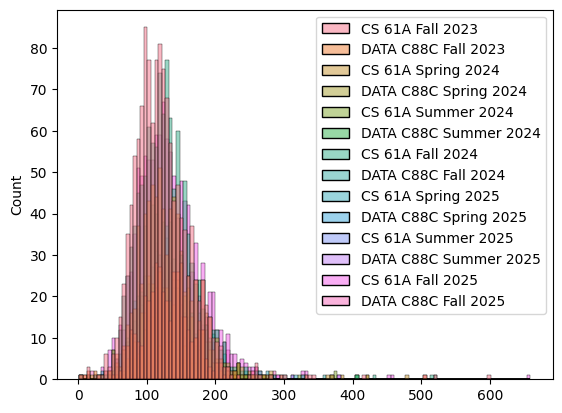

In [121]:
sns.histplot(data=results["time_between_backups"])

<Axes: ylabel='Percent'>

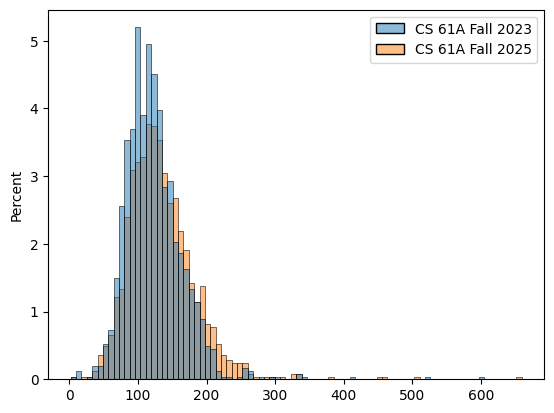

In [122]:
sns.histplot(
    data={
        key: val
        for key, val in results["time_between_backups"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
    stat="percent",
)

<Axes: ylabel='Percent'>

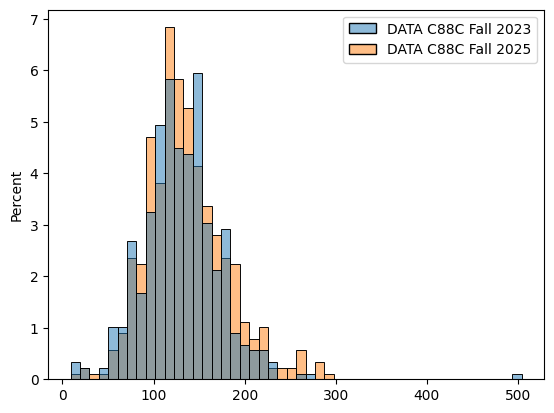

In [123]:
sns.histplot(
    data={
        key: val
        for key, val in results["time_between_backups"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
    stat="percent",
)

In [124]:
median_time_btwn_backups = {
    "Course": [],
    "Term": [],
    "Median time between backups (sec)": [],
}

for course, cur in zip(courses, cursors):
    median_time_btwn_backups["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    median_time_btwn_backups["Term"].append(course.term_string.upper())
    median_time_btwn_backups[
        "Median time between backups (sec)"
    ].append(np.median(results["time_between_backups"][course]))

<Axes: xlabel='Term', ylabel='Median time between backups (sec)'>

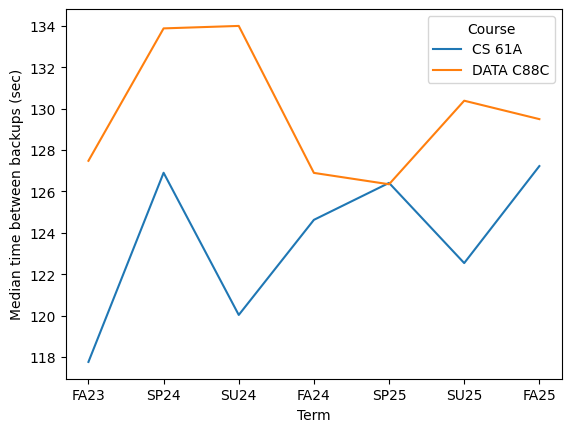

In [125]:
sns.lineplot(
    data=median_time_btwn_backups,
    x="Term",
    y="Median time between backups (sec)",
    hue="Course",
)

## Number of lines

In [126]:
NET_NUM_LINES_QUERY = """
WITH backup_line_counts AS (
    SELECT
        m.student_email,
        m.course,
        m.assignment,
        m.created,
        f.file_name,
        f.num_lines
    FROM backup_metadata AS m
    JOIN backup_file_metadata AS f
    ON m.file_contents_location = f.file_contents_location
),

consecutive_changes AS (
    -- Step 2: Use LAG to find the line count of the previous backup
    SELECT
        student_email,
        course,
        assignment,
        created,
        file_name,
        num_lines AS current_lines,
        LAG(num_lines) OVER (
            PARTITION BY student_email, course, assignment, file_name
            ORDER BY created ASC
        ) AS prev_lines
    FROM backup_line_counts
),

-- each row is a student's backup with line diff count
line_diffs AS (
    SELECT
        student_email,
        course,
        assignment,
        file_name,
        created,
        current_lines,
        prev_lines,
        -- for first backup, there is no prev_lines
        (current_lines - IFNULL(prev_lines, current_lines)) AS lines_diff
    FROM consecutive_changes
    ORDER BY student_email, created ASC
)

SELECT
    student_email,
    AVG(lines_diff)
FROM line_diffs
GROUP BY student_email
ORDER BY AVG(lines_diff) DESC, student_email
"""

def net_num_lines_added(cursor: sqlite3.Cursor) -> np.array:
    cursor.execute(NET_NUM_LINES_QUERY)
    return [row[1] for row in cursor.fetchall()]

In [127]:
results["net_num_lines_added"] = {}

for course, cur in zip(courses, cursors):
    results["net_num_lines_added"][course] = net_num_lines_added(cur)

<Axes: ylabel='Count'>

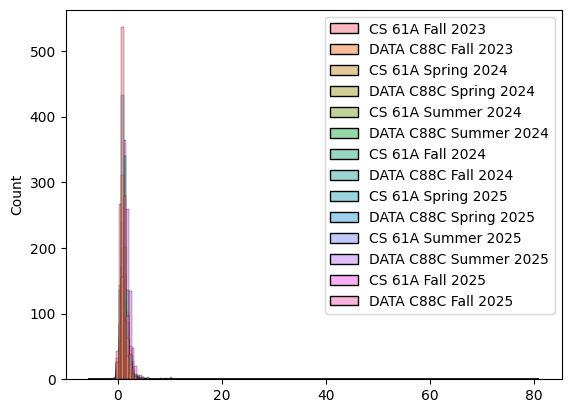

In [128]:
sns.histplot(data=results["net_num_lines_added"])

<Axes: ylabel='Count'>

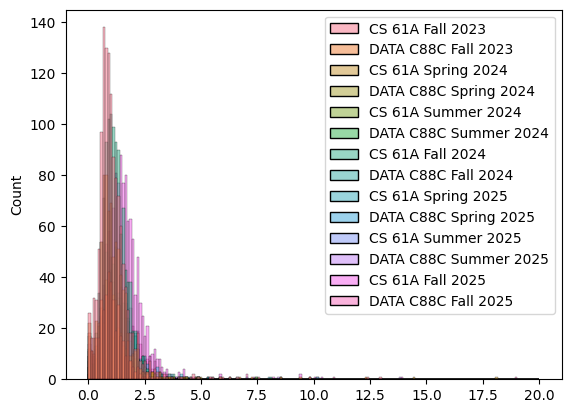

In [129]:
sns.histplot(data=results["net_num_lines_added"], binrange=(0, 20))

<Axes: ylabel='Percent'>

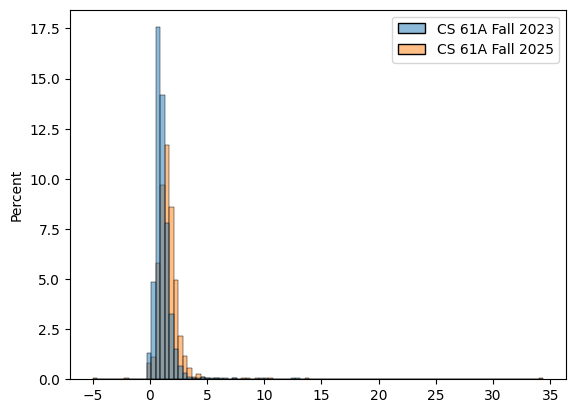

In [130]:
sns.histplot(
    data={
        key: val
        for key, val in results["net_num_lines_added"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
    stat="percent",
)

<Axes: ylabel='Percent'>

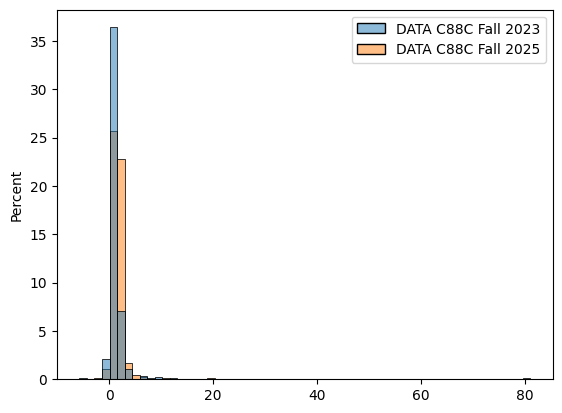

In [131]:
sns.histplot(
    data={
        key: val
        for key, val in results["net_num_lines_added"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
    stat="percent",
)

In [132]:
median_net_num_lines_added = {
    "Course": [],
    "Term": [],
    "Median net number of lines added": [],
}

for course, cur in zip(courses, cursors):
    median_net_num_lines_added["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    median_net_num_lines_added["Term"].append(course.term_string.upper())
    median_net_num_lines_added[
        "Median net number of lines added"
    ].append(np.median(results["net_num_lines_added"][course]))

<Axes: xlabel='Term', ylabel='Median net number of lines added'>

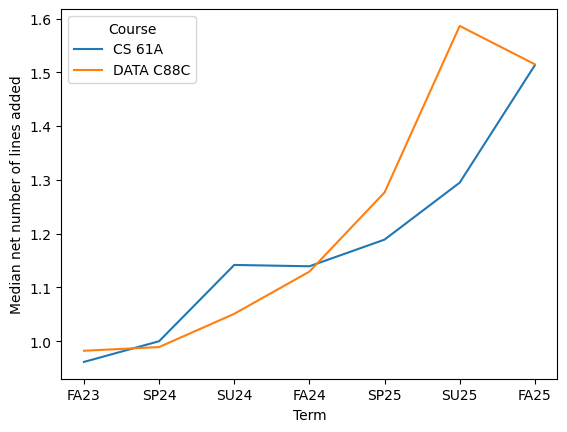

In [133]:
sns.lineplot(
    data=median_net_num_lines_added,
    x="Term",
    y="Median net number of lines added",
    hue="Course",
)

## Print debugging

In [ ]:
# TODO user generated only
# TODO how much is there?
# TODO is it successful? (define "success" as all tests passing for problem within 5 backups)

## Unlocking tests

In [ ]:
# TODO do people spam unlock message cases?
# TODO do people code before doing unlocking tests? (e.g. is there file diff for unlocking backups?)

## Lint Errors

## Across all backups

In [ ]:
# TODO

## Only final backup

In [ ]:
# TODO

## Group by problem and worksession

In [ ]:
# TODO be consistent with snapshots tool definition
# TODO num backups / absolute duration per problem?
# TODO num backups / absolute duration per worksession?

## "Calendar heatmap" barplot equivalent

In [ ]:
# TODO x-axis: relative days into project, y-axis: number of students who worked that day
# TODO ... or use heatmap instead?

## Write results to JSON

In [ ]:
with open("tech_report_results.json", "w") as f:
    json.dump(results, f)

## Teardown

In [ ]:
# Close db connection
for conn in conns:
    conn.close()